# Transcriptome and Genome - preparing gene ontology analysis
Maria B. Jelen

This script:
1. Conducts a PLS correlation analysis of AHBA gene expression (by node) with loading per node for p-factor (LV1) from rsFC PLS\n
2. Generates and exports gene lists for comparative pathway enrichment analysis in g:Profiler


In [1]:
# Import packages
import pandas as pd
import os
import numpy as np
import pyls
from matplotlib.colors import ListedColormap
import matplotlib as plt


In [2]:
# Set plotting parameters
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

In [3]:
# Set seed
np.random.seed(42)

### Preparation of psychopathology contrast in connectivity PLS loadings

In [4]:
# Load trained PLS object from resting-state fMRI PLS
import joblib

pls_membership_80_1000it = joblib.load('pls_membership_80_1000it.joblib')
print(pls_membership_80_1000it.varexp * 100)
print(pls_membership_80_1000it.permres.pvals)

[28.32386514 18.56936876 15.54025318 12.65198809 12.11816298 11.46792309
  1.32843877]
[0.000999   0.01198801 0.08691309 0.34665335 0.63436563 0.72327672
 0.5994006 ]


In [5]:
# Load thresholded fMRI data
X_df = pd.read_csv('fmri_threshold_80.csv')
X_df = X_df.sort_values(by='src_subject_id').reset_index(drop=True)
X_h = X_df.drop('src_subject_id', axis=1).values

In [ ]:
# Load AHBA data
abagen = pd.read_csv("/Volumes/astle/users/da04/PhD/abagen/expression_data_rnaseq_norm_all_interpolated/schaefer100x7_expression.csv")
print(abagen.shape)
print("Expected 100, 13562")

(100, 13562)
Expected 100, 13562


In [7]:
# Load psychopathology profile assignment data frame
Y_df = pd.read_csv('behavioral_matrix_pooled.csv')

In [8]:
# Define which profiles loaded significantly on LV1 in PLS analysis for describing contrast in connectivity. These were three profiles: cognitive, externalising and high_scores profiles
symptom_profiles = ["cognitive", "externalizing", "high_scores"]
symptoms_idx = Y_df[symptom_profiles].eq(1).any(axis=1)
noprob_idx = Y_df["noproblems"].eq(1)

In [9]:
# Transform matrices to participants x nodes x nodes
n_nodes = 100
triu_indices = np.triu_indices(n_nodes, k=1)
X_h = pd.DataFrame(X_h)
connectomes = np.zeros((X_h.shape[0], n_nodes, n_nodes))
# For each participant, reconstruct node x node matrix from upper triangle edges
for i in range(X_h.shape[0]):
    mat = np.zeros((n_nodes, n_nodes))
    mat[triu_indices] = X_h.iloc[i].values
    mat = mat + mat.T  # make matrix symmetric
    connectomes[i] = mat

print(connectomes.shape)
print("Expected 4264, 100, 100")

(4264, 100, 100)
Expected 4264, 100, 100


In [10]:
# Define symptomatic and no symptom connectome groups
symptom_connectomes = connectomes[symptoms_idx]
noprob_connectomes = connectomes[noprob_idx]

In [11]:
# Obtain difference in connectomes of participants in significant symptom profiles vs. participants without symptoms
difference_matrix = noprob_connectomes.mean(axis=0) - symptom_connectomes.mean(axis=0)

In [12]:
# Check if the psychopathology-relevant connectivity overlaps with LV1 brain map from original PLS
from brainspace.datasets import load_parcellation
atlas = load_parcellation("schaefer", scale=100, join = True)
print(atlas.shape)

from neuromaps.datasets import fetch_fslr
surfaces = fetch_fslr()
lh, rh = surfaces['inflated']

(64984,)


In [13]:
# Define custom color map
from matplotlib.colors import LinearSegmentedColormap
colors = ["#025358","#238B8B", "#FFFFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

In [14]:
# Create surface plot mapping function
from surfplot import Plot

def data_to_surfdata(data, atlas, shift=False):
    label_to_data = dict(enumerate(data.flatten(), start=1 if shift else 0))
    surfdata = np.array([label_to_data.get(label, 0) for label in atlas])
    return surfdata

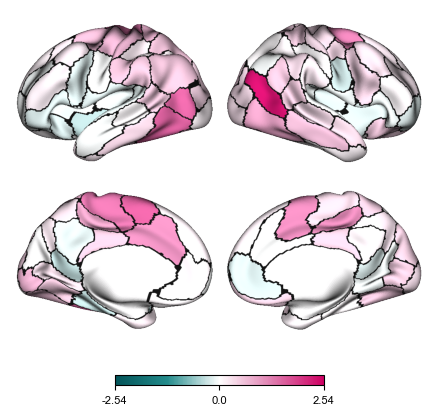

In [15]:
# Sum connectivity per node
diff_sum_LV1 = difference_matrix.sum(axis=1)

# Calculate maximum for range of connections
abs_max_cleaned_LV1 = np.nanmax(np.abs(diff_sum_LV1))

# Apply surface mapping function
surf_diff_sum_LV1 = data_to_surfdata(diff_sum_LV1, atlas,shift=True)

p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.8)
p.add_layer(surf_diff_sum_LV1,
    cmap=custom_cmap,
    cbar=True,
    color_range=(-abs_max_cleaned_LV1, abs_max_cleaned_LV1),
    zero_transparent=False),
custom_outline = ListedColormap(["#000000FF",'#ffffff']) #black outline of regions"

p.add_layer(atlas,
    cmap=custom_outline,
    as_outline=True,
    cbar=False)

kws = {'fontsize': 8, 'shrink': 0.45}

fig = p.build(cbar_kws=kws)
#fig.savefig("diff_plot.pdf", dpi=600, bbox_inches='tight') 

# visually assessed - good alignment with the brain map from direct PLS loadings


### PLS Correlation between gene expression per node and psychopathology-relevant connectivity contrast per node

In [ ]:
# Differences node sum PLS model
from sklearn.preprocessing import StandardScaler

# Save as data frame
diff_sum_LV1 = pd.DataFrame(diff_sum_LV1, columns=['Node_diff_sum_LV1'])

# Check for NaN values
print(f"Number of NaN values in abagen: {abagen.isna().sum().sum()}"),
print(f"Number of NaN values in LV1: {diff_sum_LV1.isna().sum().sum()}"),

# Separate the IDs from the data
abagen_h = abagen.drop('label', axis=1).values
abagen_h = pd.DataFrame(abagen_h)

# Select only left hemisphere (first 50 nodes)
abagen_left = abagen_h.iloc[:50, :]
diff_sum_LV1_left = diff_sum_LV1.iloc[:50, :]
 
# Scale
abagen_scaled_left = StandardScaler().fit_transform(abagen_left)
diff_sum_LV1_scaled_left = StandardScaler().fit_transform(diff_sum_LV1_left)


print(f"Shape of abagen_scaled: {abagen_scaled_left.shape}")
print(f"Shape of diff_sum_LV1_scaled: {diff_sum_LV1_scaled_left.shape}")

Number of NaN values in abagen: 0
Number of NaN values in LV1: 0
Shape of abagen_scaled: (50, 13561)
Shape of diff_sum_LV1_scaled: (50, 1)


In [ ]:
#pls_abagen_diff_left = pyls.behavioral_pls(
#    abagen_scaled_left,
#    diff_sum_LV1_scaled_left,
#    n_perm=5000,
#    n_boot=1000)

# joblib.dump(pls_abagen_diff_left, 'pls_abagen_diff_left.joblib')

In [19]:
# load ppls_abagen_diff_left model
pls_abagen_diff_left = joblib.load('pls_abagen_diff_left.joblib')
print("Variance Explained (%):")
print(pls_abagen_diff_left.varexp * 100)
print("P-values:")
print(pls_abagen_diff_left.permres.pvals)

Variance Explained (%):
[100.]
P-values:
[0.04439112]


In [ ]:
# Extract weights and bootstrap ratios
raw_x_loadings = pls_abagen_diff_left['x_weights']  # shape: (n_edges, n_LVs)
bootstrap_x_loadings = pls_abagen_diff_left['bootres']['x_weights_normed']  # shape: (n_edges, n_LVs)

print(raw_x_loadings.shape)

(13561, 1)


In [21]:
# Calculate loadings

gene_numeric = np.array(abagen_left, dtype=float)  # shape: (n_subjects, n_genes)
x_scores = pls_abagen_diff_left.x_scores  # shape: (n_subjects, n_LVs)
n_genes = gene_numeric.shape[1]
n_LVs = x_scores.shape[1]

gene_loadings = np.zeros((n_genes, n_LVs))

for lv in range(n_LVs):
    for i in range(n_genes):
        gene_loadings[i, lv] = np.corrcoef(gene_numeric[:, i], x_scores[:, lv])[0, 1]

gene_bsr = pls_abagen_diff_left.bootres.x_weights_normed[:, 0]  # LV1

print("Min:", np.min(gene_bsr))
print("Max:", np.max(gene_bsr))

Min: -6.103651708941244
Max: 6.85733362075069


In [25]:
# Threshold by BSR

gene_names = list(abagen.columns[1:]) 
gene_names = np.array(gene_names)

bsr_threshold = 2.58 # = 0.01
stable_idx = np.abs(gene_bsr) >= bsr_threshold

gene_idx = stable_idx & (gene_loadings[:,0] !=0)

stable_genes_left = gene_names[gene_idx]

print(f"All stable genes: {len(stable_genes_left)}")

All stable genes: 1634


In [26]:
print(stable_genes_left)

['A1BG' 'A4GALT' 'AATK' ... 'ZW10' 'ZWILCH' 'ZWINT']


#### Load the list manually scoped from GWASs
GWASES were found for ADHD2022, Anxiety2024, Bipolar2024, BIP2-2021, MDD2025, PTSD2024, SUD2023. Not found for Autism2022 - paper does not share findings, details in manuscript.

In [27]:
with open("GWASlist.txt", "r", encoding="utf-8-sig") as f:
    text = f.read()

genes_gwas = [g.strip() for g in text.split(",") if g.strip()]

print(genes_gwas[:20])

['PPIH', 'C1orf210', 'ELOVL1', 'MED8', 'SZT2', 'HYI', 'PTPRF', 'ST3GAL3', 'ARTN', 'B4GALT2', 'KAT2B', 'FAM198A', 'SNRK', 'ANO10', 'ABHD5', 'ZNF852', 'ZNF660', 'ZNF197', 'GPX1', 'RHOA']


In [28]:
# overlap
gene_overlap = set(genes_gwas) & set(stable_genes_left)

print("How many overlapping genes:", len(gene_overlap))
print("Genes in ABAGEN PLS and GWAS:", gene_overlap)

How many overlapping genes: 39
Genes in ABAGEN PLS and GWAS: {'ST8SIA1', 'TBR1', 'ZNF423', 'CYP7B1', 'WDR6', 'ANK3', 'SCN2A', 'PACSIN2', 'SPPL3', 'FTO', 'CDH22', 'C8orf82', 'DAG1', 'CHCHD3', 'SLC25A12', 'KIF1A', 'HDAC5', 'CD47', 'NAV3', 'PEBP1', 'MKRN1', 'GPM6A', 'GTF2IRD1', 'ARID4A', 'DLST', 'FAM120A', 'NAV1', 'ESRRG', 'GNAO1', 'NTRK3', 'PRR16', 'BRWD1', 'NDST3', 'PLXNA4', 'USP19', 'ATP8A2', 'UBE3B', 'COL19A1', 'TRAIP'}


In [29]:
# Clear from duplicates for GOenrichment
genelist_gwas_clean = set(genes_gwas)
genelist_abagenleft_clean = set(stable_genes_left)

print("Length of GWAS genes clean:", len(genelist_gwas_clean))
print("Length of ABAGEN PLS left hemi:", len(genelist_abagenleft_clean))

Length of GWAS genes clean: 570
Length of ABAGEN PLS left hemi: 1634


In [ ]:
# Save as txt files for g:Profiler
with open("genelist_gwas_clean.txt", "w") as f:
    f.write("\n".join(genelist_gwas_clean))

with open("genelist_abagenleft_clean.txt", "w") as f:
    f.write("\n".join(genelist_abagenleft_clean))